### Part I: Data Cleaning

In [14]:
import pandas as pd
import glob
import re
import os

In [23]:
df = pd.read_csv("foi_folder/foitext2015.txt", sep="|",encoding='latin1')
df.head()

,MDR_REPORT_KEY,MDR_TEXT_KEY,TEXT_TYPE_CODE,PATIENT_SEQUENCE_NUMBER,DATE_REPORT,FOI_TEXT
0,2296019,2210276,D,1,NaN,IT WAS REPORTED THAT THE PT IS ALLEGING HARM C...
1,2686192,2859246,D,1,NaN,IT WAS REPORTED BY THE PT'S ATTORNEY THAT AFTE...
2,4068041,4815655,D,1,NaN,CORMET REVISION AFTER 7 YEARS 7 MONTHS.
3,4234467,4998333,D,1,NaN,IT WAS REPORTED THAT THE PATIENT HAD A RIGHT K...
4,4376505,5112194,D,1,NaN,"ON (B)(6) 2014, THE REPORTER CONTACTED LIFESCA..."


In [24]:
print(df['FOI_TEXT'][4])

ON (B)(6) 2014, THE REPORTER CONTACTED LIFESCAN (B)(4), ALLEGING BLOOD READING AS CONTROL. THIS COMPLAINT IS BEING REPORTED BECAUSE THE REPORTED ISSUE WAS NOT RESOLVED WITH TROUBLESHOOTING. THERE WAS NO INDICATION THAT THE PRODUCT CAUSED OR CONTRIBUTED TO AN ADVERSE EVENT.


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2072407 entries, 0 to 2072406
Data columns (total 6 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   MDR_REPORT_KEY           int64  
 1   MDR_TEXT_KEY             int64  
 2   TEXT_TYPE_CODE           object 
 3   PATIENT_SEQUENCE_NUMBER  int64  
 4   DATE_REPORT              float64
 5   FOI_TEXT                 object 
dtypes: float64(1), int64(3), object(2)
memory usage: 94.9+ MB


In [15]:
#Combine all docyment dataframes
path = "foi_folder/foitext*.txt"
dfs = []

for file in glob.glob(path):

    # Extract year from filename
    filename = os.path.basename(file)
    year = re.search(r'\d{4}', filename).group()

    # Read file
    df = pd.read_csv(file, sep="|", dtype=str,encoding='latin1')

    # Add year column to compensate empty Date_Report
    df["YEAR"] = int(year)

    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)

In [16]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46396213 entries, 0 to 46396212
Data columns (total 7 columns):
 #   Column                   Dtype 
---  ------                   ----- 
 0   MDR_REPORT_KEY           object
 1   MDR_TEXT_KEY             object
 2   TEXT_TYPE_CODE           object
 3   PATIENT_SEQUENCE_NUMBER  object
 4   DATE_REPORT              object
 5   FOI_TEXT                 object
 6   YEAR                     int64 
dtypes: int64(1), object(6)
memory usage: 2.4+ GB


In [17]:
#Manually change INT back from object after concat 
combined_df["MDR_REPORT_KEY"] = pd.to_numeric(combined_df["MDR_REPORT_KEY"], errors="coerce")
combined_df["MDR_TEXT_KEY"] = pd.to_numeric(combined_df["MDR_TEXT_KEY"], errors="coerce")
combined_df["PATIENT_SEQUENCE_NUMBER"] = pd.to_numeric(combined_df["PATIENT_SEQUENCE_NUMBER"], errors="coerce")

In [18]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46396213 entries, 0 to 46396212
Data columns (total 7 columns):
 #   Column                   Dtype 
---  ------                   ----- 
 0   MDR_REPORT_KEY           int64 
 1   MDR_TEXT_KEY             int64 
 2   TEXT_TYPE_CODE           object
 3   PATIENT_SEQUENCE_NUMBER  int64 
 4   DATE_REPORT              object
 5   FOI_TEXT                 object
 6   YEAR                     int64 
dtypes: int64(4), object(3)
memory usage: 2.4+ GB


In [6]:
combined_df.describe()
#Note all Date_Report is NaN

,MDR_REPORT_KEY,MDR_TEXT_KEY,TEXT_TYPE_CODE,PATIENT_SEQUENCE_NUMBER,DATE_REPORT,FOI_TEXT
count,46396213,46396213,46396213,46396213,0,46386307
unique,19419076,46396213,2,9,0,18384552
top,5435975,51790838,N,0,NaN,(B)(4).
freq,742,1,23685972,28653165,NaN,2530714


### Part II: NLP

In [19]:
#Text cleaning
combined_df['FOI_TEXT'] = combined_df['FOI_TEXT'].str.lower()
combined_df['FOI_TEXT'] = combined_df['FOI_TEXT'].str.replace(r'[^\w\s]', '', regex=True)

In [26]:
#Common Phrases
vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,3),
    min_df=20
)

X = vectorizer.fit_transform(combined_df["FOI_TEXT"].dropna())

phrases = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

phrases_top_results = sorted(zip(phrases, counts), key=lambda x: x[1], reverse=True)

print(phrases_top_results[:10])


KeyboardInterrupt



### Part 1: Data Cleaning

In [1]:
pip install polars

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Read Datasets
import polars as pl
import glob
import os
import re

dfs = []

for file in glob.glob("foi_folder/foitext*.txt"):

    filename = os.path.basename(file)
    year = int(re.search(r"\d{4}", filename).group())

    df = pl.read_csv(
        file,
        separator="|",
        encoding="utf8-lossy",
        columns=["MDR_REPORT_KEY", "FOI_TEXT"]
    ).with_columns(
        pl.lit(year).alias("YEAR")
    )

    dfs.append(df)

combined_df = pl.concat(dfs)

In [8]:
#combined_df.write_csv("d1.csv")

In [3]:
#Remove Null
combined_df = combined_df.drop_nulls("FOI_TEXT")

### Part 2: NLP

In [4]:
#text clean
combined_df = combined_df.with_columns(
    pl.col("FOI_TEXT")
    .str.to_lowercase()
    .str.replace_all(r"[^a-z\s]", "")
)

In [20]:
#Remove stopwirds, transform and vectorize, and get word frequency 
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english')

X = vectorizer.fit_transform(combined_df['FOI_TEXT'].dropna())

word_counts = X.sum(axis=0)

words_freq = [(word, word_counts[0, idx]) for word, idx in vectorizer.vocabulary_.items()]

words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

words_freq[:20]

[('device', 41421337),
 ('report', 40239144),
 ('reported', 39017209),
 ('information', 35904232),
 ('patient', 25149541),
 ('event', 22392479),
 ('medtronic', 17946365),
 ('product', 17517436),
 ('returned', 13548072),
 ('available', 12060330),
 ('implant', 11976890),
 ('investigation', 11492277),
 ('customer', 11392476),
 ('provided', 10877510),
 ('b6', 10809529),
 ('received', 10266639),
 ('fda', 10243603),
 ('additional', 10174684),
 ('b4', 9689894),
 ('date', 9658533)]

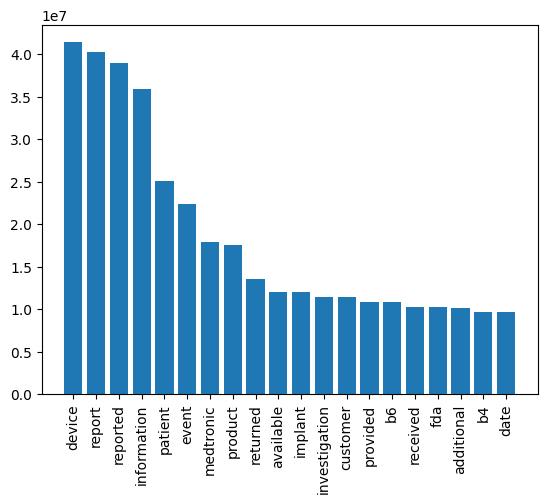

In [21]:
import matplotlib.pyplot as plt

top_words = dict(words_freq[:20])

plt.bar(top_words.keys(), top_words.values())
plt.xticks(rotation=90)
plt.show()

In [5]:
from sklearn.feature_extraction.text import CountVectorizer

texts = combined_df["FOI_TEXT"].to_list()

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2,2),
    min_df=10
)

X = vectorizer.fit_transform(texts)

phrases = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

results = sorted(zip(phrases, counts), key=lambda x: x[1], reverse=True)

print(results[:20])

[('information available', 7763124), ('caused contributed', 5701901), ('supplemental report', 5546127), ('information provided', 5227448), ('additional information', 5157216), ('date report', 4987465), ('report does', 4898114), ('described report', 4869995), ('contributed event', 4631228), ('does constitute', 4291433), ('constitute admission', 4278802), ('fda medtronic', 4214406), ('medtronic employees', 4116314), ('relevant information', 4077843), ('device returned', 4058878), ('report submitted', 3923804), ('product returned', 3835727), ('blood glucose', 3692175), ('reported patient', 3651765), ('medical intervention', 3547158)]


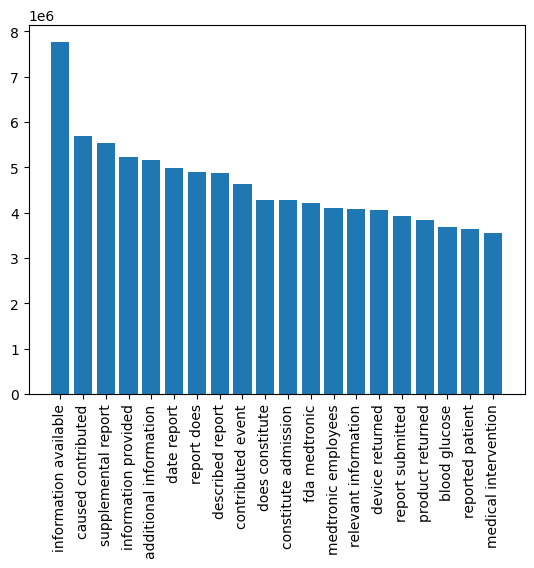

In [6]:
import matplotlib.pyplot as plt

top_words = dict(results[:20])

plt.bar(top_words.keys(), top_words.values())
plt.xticks(rotation=90)
plt.show()

In [10]:
#Bigram again with custom stop words added
from sklearn.feature_extraction import text
custom_stop_words = {"information", "contributed", "device","report",'constitute'}
english_stop_words = text.ENGLISH_STOP_WORDS
all_stop_words = list(english_stop_words.union(custom_stop_words))


In [11]:
vectorizer2 = CountVectorizer(
    stop_words=all_stop_words,
    ngram_range=(2,2),
    min_df=10
)

X2 = vectorizer2.fit_transform(texts)

phrases2 = vectorizer2.get_feature_names_out()
counts2 = X2.sum(axis=0).A1

results2 = sorted(zip(phrases2, counts2), key=lambda x: x[1], reverse=True)

print(results2[:20])

[('caused event', 4406469), ('does admission', 4278699), ('fda medtronic', 4214410), ('medtronic employees', 4116314), ('product returned', 3855226), ('blood glucose', 3692175), ('reported patient', 3664418), ('medical intervention', 3547162), ('insulin pump', 3413991), ('event described', 3270333), ('date does', 3207107), ('currently unknown', 3200343), ('intervention reported', 2984871), ('et al', 2977668), ('conclusion fda', 2911758), ('relevant available', 2841149), ('root cause', 2740587), ('admission conclusion', 2623208), ('submission date', 2617953), ('available company', 2604739)]


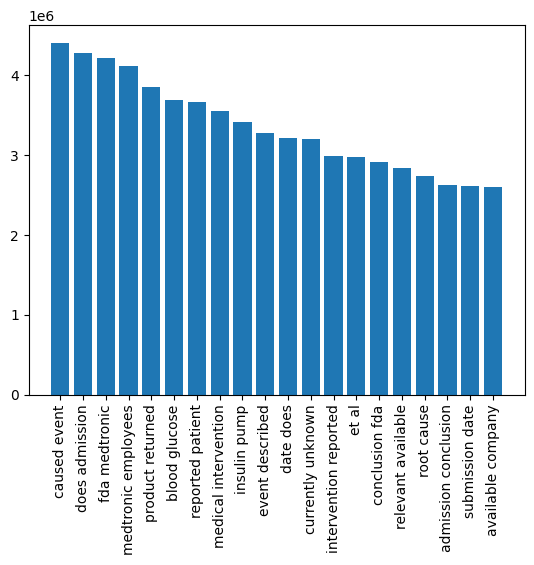

In [13]:
import matplotlib.pyplot as plt

top_words = dict(results2[:20])

plt.bar(top_words.keys(), top_words.values())
plt.xticks(rotation=90)
plt.show()

In [14]:
complaints_by_year = (
    combined_df
    .groupby("YEAR")
    .agg(pl.count().alias("num_complaints"))
    .sort("YEAR")
)
print(complaints_by_year)

/scratch/3672245.1.csgpu/ipykernel_1119637/1776965100.py:3: DeprecationWarning: `groupby` is deprecated. It has been renamed to `group_by`.
  .groupby("YEAR")
/scratch/3672245.1.csgpu/ipykernel_1119637/1776965100.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  .agg(pl.count().alias("num_complaints"))


shape: (11, 2)
┌──────┬────────────────┐
│ YEAR ┆ num_complaints │
│ ---  ┆ ---            │
│ i32  ┆ u32            │
╞══════╪════════════════╡
│ 2015 ┆ 2048638        │
│ 2016 ┆ 2189761        │
│ 2017 ┆ 2401973        │
│ 2018 ┆ 2777677        │
│ 2019 ┆ 3380124        │
│ 2020 ┆ 3952027        │
│ 2021 ┆ 4753522        │
│ 2022 ┆ 6516851        │
│ 2023 ┆ 5368226        │
│ 2024 ┆ 5915540        │
│ 2025 ┆ 6238528        │
└──────┴────────────────┘


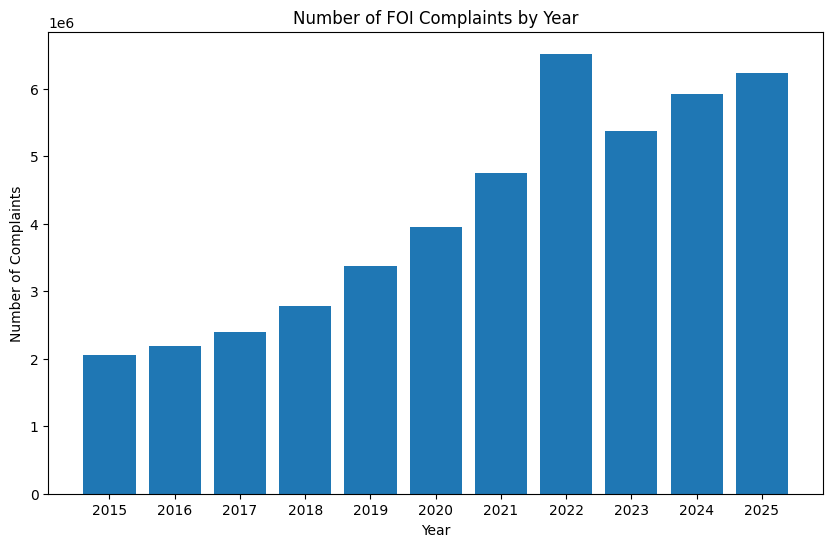

In [15]:
df_plot = complaints_by_year.to_pandas()

plt.figure(figsize=(10,6))
plt.bar(df_plot["YEAR"], df_plot["num_complaints"])
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.title("Number of FOI Complaints by Year")
plt.xticks(df_plot["YEAR"])
plt.show()